# Predicting Irrigation Need: ResMLP + sklearn + XGBoost + LightGBM + CatBoost + K-fold blending


- `StratifiedKFold` 做 K-fold 验证
- 所有基模型都基于 OOF(out-of-fold) 概率做评估
- blending 权重在 OOF 概率上自动搜索
- `XGBClassifier` 在每个 fold 上用验证折做 early stopping
- 最终测试集概率为各 fold 概率平均


In [1]:
import copy
import os
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


In [2]:
# 读入数据
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

y = train["Irrigation_Need"]
X_train_raw = train.drop(columns=["Irrigation_Need"]).copy()
X_test_raw = test.copy()

n_train = len(train)
n_test = len(test)

# 保留原来的联合预处理思路
full = pd.concat([X_train_raw, X_test_raw], axis=0).reset_index(drop=True)
full = pd.get_dummies(full, drop_first=True)

if "id" in full.columns:
    full = full.drop(columns=["id"])

X_all = full.iloc[:n_train].copy()
X_test = full.iloc[n_train:].copy()

# 标签编码
y_cat = pd.Categorical(y)
y_code = y_cat.codes.astype(np.int64)
class_names = list(y_cat.categories)
num_class = len(class_names)

print("X_all:", X_all.shape)
print("X_test:", X_test.shape)
print("num_class:", num_class)


X_all: (630000, 35)
X_test: (270000, 35)
num_class: 3


## 数据集可视化


,Irrigation_Need,count,ratio
0,High,21009,0.033348
1,Low,369917,0.587170
2,Medium,239074,0.379483


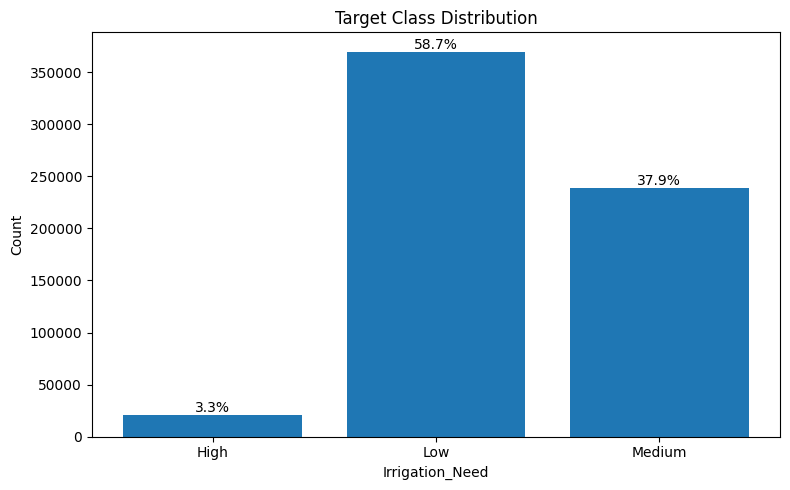

saved: report_figures\01_target_distribution.png


In [3]:
# 可视化输出目录
FIG_DIR = "report_figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

# 1) 标签分布图
class_count_df = (
    pd.Series(y, name="Irrigation_Need")
    .value_counts()
    .sort_index()
    .rename_axis("Irrigation_Need")
    .reset_index(name="count")
)
class_count_df["ratio"] = class_count_df["count"] / class_count_df["count"].sum()
display(class_count_df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(class_count_df["Irrigation_Need"].astype(str), class_count_df["count"])
ax.set_title("Target Class Distribution")
ax.set_xlabel("Irrigation_Need")
ax.set_ylabel("Count")
for i, row in class_count_df.iterrows():
    ax.text(i, row["count"], f'{row["ratio"]:.1%}', ha="center", va="bottom")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_target_distribution.png"), dpi=220, bbox_inches="tight")
plt.show()

print("saved:", os.path.join(FIG_DIR, "01_target_distribution.png"))

In [4]:
# 概率安全处理：避免 log_loss 因为“每行和不等于 1”报警
def safe_normalize_prob(prob, eps=1e-15):
    prob = np.asarray(prob, dtype=np.float64)
    prob = np.nan_to_num(prob, nan=eps, posinf=1.0, neginf=eps)
    prob = np.clip(prob, eps, 1.0)
    row_sum = prob.sum(axis=1, keepdims=True)
    row_sum = np.where(row_sum <= 0, 1.0, row_sum)
    prob = prob / row_sum
    return prob

def print_prob_stats(name, prob):
    row_sum = prob.sum(axis=1)
    print(
        f"{name:>5s} prob row-sum min={row_sum.min():.8f}, "
        f"max={row_sum.max():.8f}, "
        f"nan={np.isnan(prob).any()}, inf={np.isinf(prob).any()}"
    )


class ResidualBlock(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        identity = x
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = out + identity
        out = self.relu(out)
        return out


class ResMlP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, 128)
        self.blocks = nn.Sequential(
            ResidualBlock(128, 128, dropout=0.1),
            ResidualBlock(128, 128, dropout=0.1),
            ResidualBlock(128, 128, dropout=0.1),
        )
        self.head = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.input_layer(x)
        x = torch.relu(x)
        x = self.blocks(x)
        x = self.head(x)
        return x


In [5]:
# 训练配置
K_FOLDS = 5
BATCH_SIZE = 64
NN_EPOCHS = 10
NN_LR = 1e-3
USE_TENSORBOARD = False

xgb_params = {
    'learning_rate': 0.03,
    'max_depth': 4,
    'min_child_weight': 2,
    'subsample': 0.98,
    'gamma': 4.2,
    'colsample_bytree': 0.5,
    'lambda': 0.001,
    'alpha': 4.1,
    'n_estimators': 50_000,
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'device': 'cuda',
}

lgbm_params = {
    "objective": "multiclass",
    "num_class": num_class,
    "n_estimators": 3000,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
}

cat_params = {
    "loss_function": "MultiClass",
    "iterations": 5000,
    "learning_rate": 0.03,
    "depth": 6,
    "random_seed": SEED,
    "verbose": False,
}

print("K_FOLDS =", K_FOLDS)


K_FOLDS = 5


In [6]:
def train_nn_one_fold(X_tr, y_tr, X_va, y_va, X_te, fold_id):
    X_tr_tensor = torch.tensor(X_tr, dtype=torch.float32)
    X_va_tensor = torch.tensor(X_va, dtype=torch.float32)
    X_te_tensor = torch.tensor(X_te, dtype=torch.float32)
    y_tr_tensor = torch.tensor(y_tr, dtype=torch.long)
    y_va_tensor = torch.tensor(y_va, dtype=torch.long)

    train_dataset = TensorDataset(X_tr_tensor, y_tr_tensor)
    val_dataset = TensorDataset(X_va_tensor, y_va_tensor)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = ResMlP(X_tr.shape[1], num_class).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=NN_LR)

    best_state = None
    best_val_acc = -1.0

    for epoch in range(NN_EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = loss_fn(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        total_correct = 0
        total_count = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                logits = model(xb)
                pred = logits.argmax(dim=1)
                total_correct += (pred == yb).sum().item()
                total_count += xb.size(0)

        val_acc = total_correct / total_count
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()

    with torch.no_grad():
        val_logits = model(X_va_tensor.to(device))
        test_logits = model(X_te_tensor.to(device))

    val_prob = torch.softmax(val_logits, dim=1).cpu().numpy()
    test_prob = torch.softmax(test_logits, dim=1).cpu().numpy()

    val_prob = safe_normalize_prob(val_prob)
    test_prob = safe_normalize_prob(test_prob)

    print(f"fold {fold_id} | nn best val acc: {best_val_acc:.6f}")
    return val_prob, test_prob


def build_sklearn_models():
    xgb_fold_params = xgb_params.copy()
    if not torch.cuda.is_available():
        xgb_fold_params["device"] = "cpu"

    models = {
        "lr": LogisticRegression(
            max_iter=3000,
            random_state=SEED
        ),
        "rf": RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            random_state=SEED,
            n_jobs=-1
        ),
        "et": ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=SEED,
            n_jobs=-1
        ),
        "hgb": HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            max_depth=6,
            random_state=SEED
        ),
        "xgb": XGBClassifier(
            **xgb_fold_params,
            num_class=num_class,
            random_state=SEED,
            early_stopping_rounds=200,
            verbosity=0,
        ),
        "lgbm": LGBMClassifier(
            **lgbm_params
        ),
        "cat": CatBoostClassifier(
            **cat_params
        ),
    }
    return models


In [7]:
# K-fold OOF 训练
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

model_names = ["nn", "lr", "rf", "et", "hgb", "xgb", "lgbm", "cat"]
oof_probs = {
    name: np.zeros((n_train, num_class), dtype=np.float64)
    for name in model_names
}
test_probs_sum = {
    name: np.zeros((n_test, num_class), dtype=np.float64)
    for name in model_names
}
fold_scores = {name: [] for name in model_names}
fold_result_rows = []

feature_names = X_all.columns.to_list()
feature_importance_records = {
    name: [] for name in ["lr", "rf", "et", "xgb", "lgbm", "cat"]
}

for fold_id, (tr_idx, va_idx) in enumerate(skf.split(X_all, y_code), start=1):
    print("=" * 70)
    print(f"Fold {fold_id}/{K_FOLDS}")

    X_tr_df = X_all.iloc[tr_idx].copy()
    X_va_df = X_all.iloc[va_idx].copy()
    y_tr = y_code[tr_idx]
    y_va = y_code[va_idx]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr_df).astype(np.float32)
    X_va = scaler.transform(X_va_df).astype(np.float32)
    X_te = scaler.transform(X_test).astype(np.float32)

    # 1) NN
    nn_val_prob, nn_test_prob = train_nn_one_fold(X_tr, y_tr, X_va, y_va, X_te, fold_id)
    oof_probs["nn"][va_idx] = nn_val_prob
    test_probs_sum["nn"] += nn_test_prob / K_FOLDS

    nn_val_pred = np.argmax(nn_val_prob, axis=1)
    nn_val_acc = accuracy_score(y_va, nn_val_pred)
    nn_val_loss = log_loss(y_va, nn_val_prob, labels=np.arange(num_class))
    fold_scores["nn"].append(nn_val_acc)
    fold_result_rows.append({
        "fold": fold_id,
        "model": "nn",
        "acc": nn_val_acc,
        "logloss": nn_val_loss,
    })
    print_prob_stats("nn", nn_val_prob)
    print(f"fold {fold_id} | nn acc: {nn_val_acc:.6f} | nn logloss: {nn_val_loss:.6f}")

    # 2) sklearn / boosting
    sk_models = build_sklearn_models()

    for name, clf in sk_models.items():
        if name == "xgb":
            clf.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                verbose=False
            )
        elif name == "lgbm":
            clf.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[lgb.early_stopping(200, verbose=False)]
            )
        elif name == "cat":
            clf.fit(
                X_tr, y_tr,
                eval_set=(X_va, y_va),
                use_best_model=True,
                verbose=False
            )
        else:
            clf.fit(X_tr, y_tr)

        val_prob = clf.predict_proba(X_va)
        test_prob = clf.predict_proba(X_te)

        val_prob = safe_normalize_prob(val_prob)
        test_prob = safe_normalize_prob(test_prob)

        oof_probs[name][va_idx] = val_prob
        test_probs_sum[name] += test_prob / K_FOLDS

        val_pred = np.argmax(val_prob, axis=1)
        val_acc = accuracy_score(y_va, val_pred)
        val_loss = log_loss(y_va, val_prob, labels=np.arange(num_class))
        fold_scores[name].append(val_acc)
        fold_result_rows.append({
            "fold": fold_id,
            "model": name,
            "acc": val_acc,
            "logloss": val_loss,
        })

        if name == "lr":
            feature_importance_records[name].append(
                np.mean(np.abs(clf.coef_), axis=0).astype(np.float64)
            )
        elif name == "cat":
            feature_importance_records[name].append(
                np.asarray(clf.get_feature_importance(), dtype=np.float64)
            )
        elif hasattr(clf, "feature_importances_"):
            feature_importance_records[name].append(
                np.asarray(clf.feature_importances_, dtype=np.float64)
            )

        print_prob_stats(name, val_prob)
        print(f"fold {fold_id} | {name} acc: {val_acc:.6f} | {name} logloss: {val_loss:.6f}")

Fold 1/5
fold 1 | nn best val acc: 0.979103
   nn prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 1 | nn acc: 0.979103 | nn logloss: 0.074642
   lr prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 1 | lr acc: 0.876159 | lr logloss: 0.285680
   rf prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 1 | rf acc: 0.985063 | rf logloss: 0.094949
   et prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 1 | et acc: 0.943659 | et logloss: 0.234300
  hgb prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 1 | hgb acc: 0.983794 | hgb logloss: 0.059341
  xgb prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 1 | xgb acc: 0.984738 | xgb logloss: 0.059604


c:\python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


 lgbm prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 1 | lgbm acc: 0.984556 | lgbm logloss: 0.057302
  cat prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 1 | cat acc: 0.985175 | cat logloss: 0.056398
Fold 2/5
fold 2 | nn best val acc: 0.979222
   nn prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 2 | nn acc: 0.979222 | nn logloss: 0.073838
   lr prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 2 | lr acc: 0.876421 | lr logloss: 0.287598
   rf prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 2 | rf acc: 0.984659 | rf logloss: 0.095535
   et prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 2 | et acc: 0.944119 | et logloss: 0.233805
  hgb prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 2 | hgb acc: 0.984040 | hgb logloss: 0.058985
  xgb prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 2 | xgb acc: 0.984278 | 

c:\python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


 lgbm prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 2 | lgbm acc: 0.984413 | lgbm logloss: 0.058116
  cat prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 2 | cat acc: 0.985087 | cat logloss: 0.057635
Fold 3/5
fold 3 | nn best val acc: 0.978175
   nn prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 3 | nn acc: 0.978175 | nn logloss: 0.076915
   lr prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 3 | lr acc: 0.876222 | lr logloss: 0.285511
   rf prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 3 | rf acc: 0.984508 | rf logloss: 0.095585
   et prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 3 | et acc: 0.943754 | et logloss: 0.235080
  hgb prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 3 | hgb acc: 0.984143 | hgb logloss: 0.059387
  xgb prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 3 | xgb acc: 0.983905 | 

...

 lgbm prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 3 | lgbm acc: 0.984333 | lgbm logloss: 0.057917
  cat prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 3 | cat acc: 0.983817 | cat logloss: 0.059486
Fold 4/5
fold 4 | nn best val acc: 0.979246
   nn prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 4 | nn acc: 0.979246 | nn logloss: 0.073939
   lr prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 4 | lr acc: 0.876024 | lr logloss: 0.287907
   rf prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 4 | rf acc: 0.985151 | rf logloss: 0.094099
   et prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 4 | et acc: 0.943294 | et logloss: 0.235902
  hgb prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 4 | hgb acc: 0.984143 | hgb logloss: 0.057848
  xgb prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 4 | xgb acc: 0.984675 | 

c:\python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


 lgbm prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 4 | lgbm acc: 0.985190 | lgbm logloss: 0.055592
  cat prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 4 | cat acc: 0.984579 | cat logloss: 0.057446
Fold 5/5
fold 5 | nn best val acc: 0.979841
   nn prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 5 | nn acc: 0.979841 | nn logloss: 0.072773
   lr prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 5 | lr acc: 0.876556 | lr logloss: 0.287233
   rf prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 5 | rf acc: 0.984698 | rf logloss: 0.094975
   et prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 5 | et acc: 0.944944 | et logloss: 0.233894
  hgb prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 5 | hgb acc: 0.984429 | hgb logloss: 0.057906
  xgb prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 5 | xgb acc: 0.984349 | 

c:\python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


 lgbm prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 5 | lgbm acc: 0.985175 | lgbm logloss: 0.055342
  cat prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False
fold 5 | cat acc: 0.984794 | cat logloss: 0.056849


In [8]:
# OOF 单模型结果
val_scores = {}
val_losses = {}

print("OOF single-model results:")
for name in model_names:
    oof_probs[name] = safe_normalize_prob(oof_probs[name])
    test_probs_sum[name] = safe_normalize_prob(test_probs_sum[name])

    pred = np.argmax(oof_probs[name], axis=1)
    acc = accuracy_score(y_code, pred)
    loss = log_loss(y_code, oof_probs[name], labels=np.arange(num_class))

    val_scores[name] = acc
    val_losses[name] = loss

    mean_fold_acc = np.mean(fold_scores[name])
    std_fold_acc = np.std(fold_scores[name])

    print(
        f"{name:>5s} | OOF acc={acc:.6f} | OOF logloss={loss:.6f} | "
        f"fold acc mean={mean_fold_acc:.6f} std={std_fold_acc:.6f}"
    )

fold_result_df = pd.DataFrame(fold_result_rows)
fold_summary_df = (
    fold_result_df.groupby("model", as_index=False)
    .agg(
        fold_acc_mean=("acc", "mean"),
        fold_acc_std=("acc", "std"),
        fold_logloss_mean=("logloss", "mean"),
        fold_logloss_std=("logloss", "std"),
    )
)

model_summary_df = pd.DataFrame({
    "model": model_names,
    "oof_acc": [val_scores[name] for name in model_names],
    "oof_logloss": [val_losses[name] for name in model_names],
}).merge(fold_summary_df, on="model", how="left")

model_summary_df = model_summary_df.sort_values(
    ["oof_acc", "oof_logloss"], ascending=[False, True]
).reset_index(drop=True)

display(model_summary_df)

OOF single-model results:
   nn | OOF acc=0.979117 | OOF logloss=0.074421 | fold acc mean=0.979117 std=0.000537
   lr | OOF acc=0.876276 | OOF logloss=0.286786 | fold acc mean=0.876276 std=0.000189
   rf | OOF acc=0.984816 | OOF logloss=0.095029 | fold acc mean=0.984816 std=0.000248
   et | OOF acc=0.943954 | OOF logloss=0.234596 | fold acc mean=0.943954 std=0.000561
  hgb | OOF acc=0.984110 | OOF logloss=0.058694 | fold acc mean=0.984110 std=0.000204
  xgb | OOF acc=0.984389 | OOF logloss=0.060134 | fold acc mean=0.984389 std=0.000301
 lgbm | OOF acc=0.984733 | OOF logloss=0.056854 | fold acc mean=0.984733 std=0.000374
  cat | OOF acc=0.984690 | OOF logloss=0.057563 | fold acc mean=0.984690 std=0.000485


,model,oof_acc,oof_logloss,fold_acc_mean,fold_acc_std,fold_logloss_mean,fold_logloss_std
0,rf,0.984816,0.095029,0.984816,0.000277,0.095029,0.000600
1,lgbm,0.984733,0.056854,0.984733,0.000418,0.056854,0.001304
2,cat,0.984690,0.057563,0.984690,0.000542,0.057563,0.001181
3,xgb,0.984389,0.060134,0.984389,0.000336,0.060134,0.000954
4,hgb,0.984110,0.058694,0.984110,0.000228,0.058694,0.000761
5,nn,0.979117,0.074421,0.979117,0.000600,0.074421,0.001546
6,et,0.943954,0.234596,0.943954,0.000627,0.234596,0.000887
7,lr,0.876276,0.286786,0.876276,0.000212,0.286786,0.001114


In [9]:
# 在 OOF 概率上自动搜索 blending 权重
oof_stack = np.stack([oof_probs[name] for name in model_names], axis=0)
test_stack = np.stack([test_probs_sum[name] for name in model_names], axis=0)

def normalize_weights(w):
    w = np.asarray(w, dtype=np.float64)
    w = np.clip(w, 0.0, None)
    s = w.sum()
    if s <= 0:
        return np.ones_like(w) / len(w)
    return w / s

def blend_prob_from_weights(weight_vec, prob_stack):
    w = normalize_weights(weight_vec)
    prob = np.tensordot(w, prob_stack, axes=(0, 0))
    prob = safe_normalize_prob(prob)
    return prob

def evaluate_weights(weight_vec):
    prob = blend_prob_from_weights(weight_vec, oof_stack)
    pred = np.argmax(prob, axis=1)
    acc = accuracy_score(y_code, pred)
    loss = log_loss(y_code, prob, labels=np.arange(num_class))
    return acc, loss, prob

def is_better(acc, loss, best_acc, best_loss, tol=1e-12):
    if acc > best_acc + tol:
        return True
    if abs(acc - best_acc) <= tol and loss < best_loss - tol:
        return True
    return False

print("individual OOF acc:")
for k, v in sorted(val_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{k:>5s}: {v:.6f}")

n_models = len(model_names)
rng = np.random.default_rng(SEED)

best_single_name = max(val_scores, key=val_scores.get)
best_weights = np.zeros(n_models, dtype=np.float64)
best_weights[model_names.index(best_single_name)] = 1.0
best_acc, best_loss, _ = evaluate_weights(best_weights)

print("\nstart search from best single model:")
print("best single:", best_single_name, "acc =", round(best_acc, 6), "logloss =", round(best_loss, 6))

# 1) 两模型精细网格搜索
grid = np.linspace(0.0, 1.0, 101)
for i in range(n_models):
    for j in range(i + 1, n_models):
        for a in grid:
            w = np.zeros(n_models, dtype=np.float64)
            w[i] = a
            w[j] = 1.0 - a
            acc, loss, _ = evaluate_weights(w)
            if is_better(acc, loss, best_acc, best_loss):
                best_acc, best_loss = acc, loss
                best_weights = w.copy()

print("after pairwise grid search:", round(best_acc, 6), "logloss =", round(best_loss, 6))

# 2) 全模型 Dirichlet 随机搜索
alphas = [0.2, 0.5, 1.0, 2.0]
n_random_per_alpha = 3000

for alpha in alphas:
    for _ in range(n_random_per_alpha):
        w = rng.dirichlet(np.full(n_models, alpha))
        acc, loss, _ = evaluate_weights(w)
        if is_better(acc, loss, best_acc, best_loss):
            best_acc, best_loss = acc, loss
            best_weights = w.copy()
    print(f"after dirichlet alpha={alpha}: acc={best_acc:.6f}, logloss={best_loss:.6f}")

# 3) 在当前最优解附近做局部扰动搜索
for sigma in [0.05, 0.02, 0.01]:
    for _ in range(4000):
        noise = rng.normal(0.0, sigma, size=n_models)
        w = normalize_weights(best_weights + noise)
        acc, loss, _ = evaluate_weights(w)
        if is_better(acc, loss, best_acc, best_loss):
            best_acc, best_loss = acc, loss
            best_weights = w.copy()
    print(f"after local search sigma={sigma}: acc={best_acc:.6f}, logloss={best_loss:.6f}")

best_weights = normalize_weights(best_weights)
weights = {name: float(best_weights[i]) for i, name in enumerate(model_names)}

blend_oof_prob = safe_normalize_prob(blend_prob_from_weights(best_weights, oof_stack))
blend_test_prob = safe_normalize_prob(blend_prob_from_weights(best_weights, test_stack))

print_prob_stats("blend", blend_oof_prob)

blend_oof_pred = np.argmax(blend_oof_prob, axis=1)
blend_oof_acc = accuracy_score(y_code, blend_oof_pred)
blend_oof_loss = log_loss(y_code, blend_oof_prob, labels=np.arange(num_class))

print("\nsearched blend OOF acc:", round(blend_oof_acc, 6))
print("searched blend OOF logloss:", round(blend_oof_loss, 6))
print("searched weights:")
for name, wt in sorted(weights.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:>5s}: {wt:.6f}")


individual OOF acc:
   rf: 0.984816
 lgbm: 0.984733
  cat: 0.984690
  xgb: 0.984389
  hgb: 0.984110
   nn: 0.979117
   et: 0.943954
   lr: 0.876276

start search from best single model:
best single: rf acc = 0.984816 logloss = 0.095029
after pairwise grid search: 0.985416 logloss = 0.08003
after dirichlet alpha=0.2: acc=0.985438, logloss=0.076809
after dirichlet alpha=0.5: acc=0.985438, logloss=0.076809
after dirichlet alpha=1.0: acc=0.985438, logloss=0.076809
after dirichlet alpha=2.0: acc=0.985438, logloss=0.076809
after local search sigma=0.05: acc=0.985465, logloss=0.077682
after local search sigma=0.02: acc=0.985465, logloss=0.077682
after local search sigma=0.01: acc=0.985468, logloss=0.077692
blend prob row-sum min=1.00000000, max=1.00000000, nan=False, inf=False

searched blend OOF acc: 0.985468
searched blend OOF logloss: 0.077692
searched weights:
   rf: 0.612876
 lgbm: 0.167739
  cat: 0.104808
  xgb: 0.061022
  hgb: 0.053556
   nn: 0.000000
   lr: 0.000000
   et: 0.000000




1. 单模型 OOF 准确率对比
2. 单模型 OOF Log Loss 对比
3. 各模型在不同 fold 上的准确率稳定性
4. blending 后的混淆矩阵
5. blending 权重分布
6. 融合后的加权特征重要性



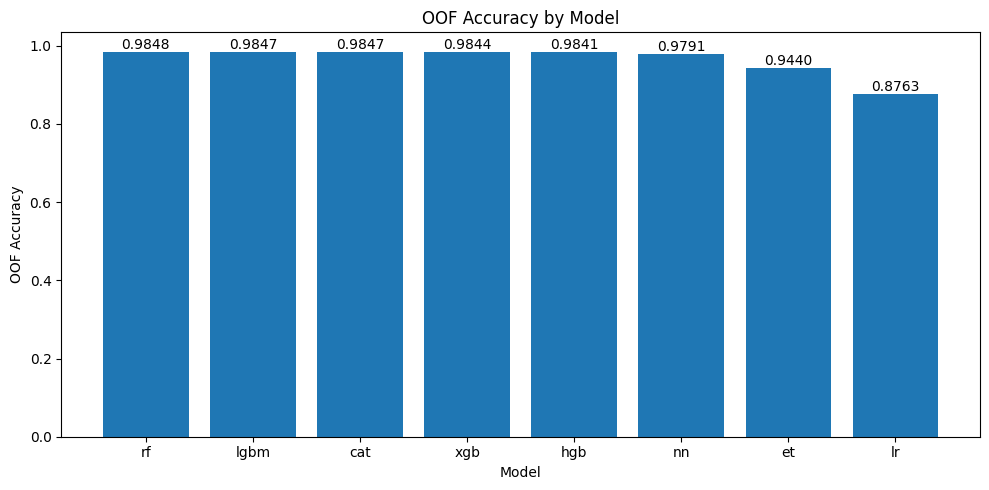

saved: report_figures\02_model_oof_accuracy.png


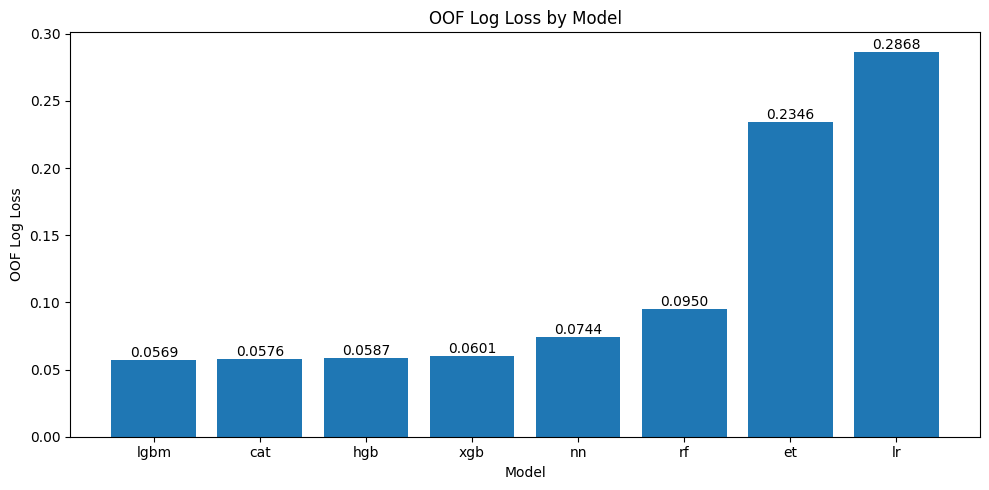

saved: report_figures\03_model_oof_logloss.png


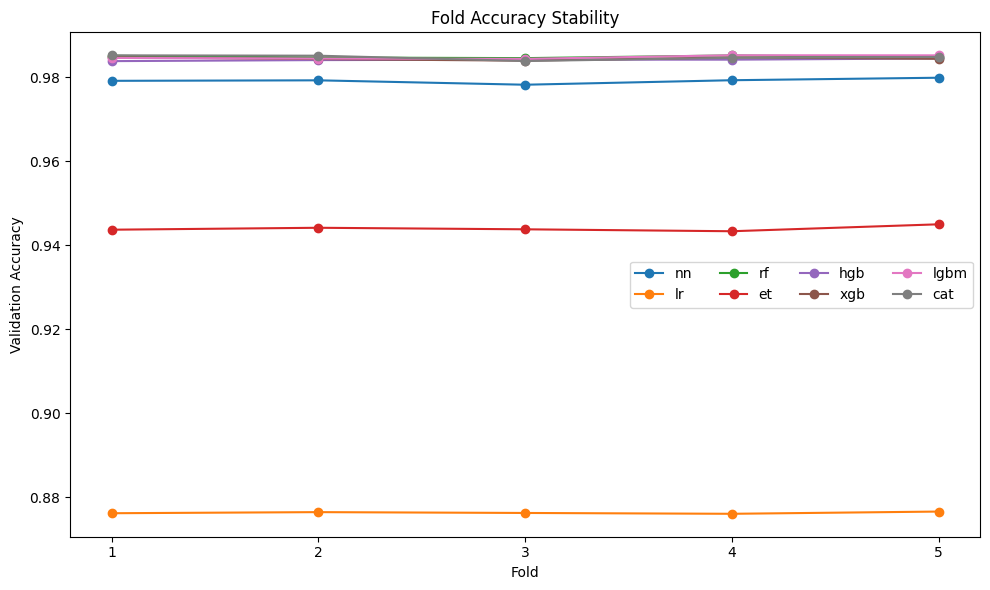

saved: report_figures\04_fold_accuracy_stability.png


In [10]:
# 2) 单模型 OOF accuracy 对比图
plot_df_acc = model_summary_df.sort_values(["oof_acc", "oof_logloss"], ascending=[False, True])
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df_acc["model"], plot_df_acc["oof_acc"])
ax.set_title("OOF Accuracy by Model")
ax.set_xlabel("Model")
ax.set_ylabel("OOF Accuracy")
for i, v in enumerate(plot_df_acc["oof_acc"]):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_model_oof_accuracy.png"), dpi=220, bbox_inches="tight")
plt.show()

print("saved:", os.path.join(FIG_DIR, "02_model_oof_accuracy.png"))

# 3) 单模型 OOF logloss 对比图
plot_df_loss = model_summary_df.sort_values(["oof_logloss", "oof_acc"], ascending=[True, False])
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df_loss["model"], plot_df_loss["oof_logloss"])
ax.set_title("OOF Log Loss by Model")
ax.set_xlabel("Model")
ax.set_ylabel("OOF Log Loss")
for i, v in enumerate(plot_df_loss["oof_logloss"]):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_model_oof_logloss.png"), dpi=220, bbox_inches="tight")
plt.show()

print("saved:", os.path.join(FIG_DIR, "03_model_oof_logloss.png"))

# 4) 各 fold 准确率稳定性图
fig, ax = plt.subplots(figsize=(10, 6))
for name in model_names:
    part = fold_result_df[fold_result_df["model"] == name].sort_values("fold")
    ax.plot(part["fold"], part["acc"], marker="o", label=name)
ax.set_title("Fold Accuracy Stability")
ax.set_xlabel("Fold")
ax.set_ylabel("Validation Accuracy")
ax.set_xticks(range(1, K_FOLDS + 1))
ax.legend(ncol=4)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_fold_accuracy_stability.png"), dpi=220, bbox_inches="tight")
plt.show()

print("saved:", os.path.join(FIG_DIR, "04_fold_accuracy_stability.png"))

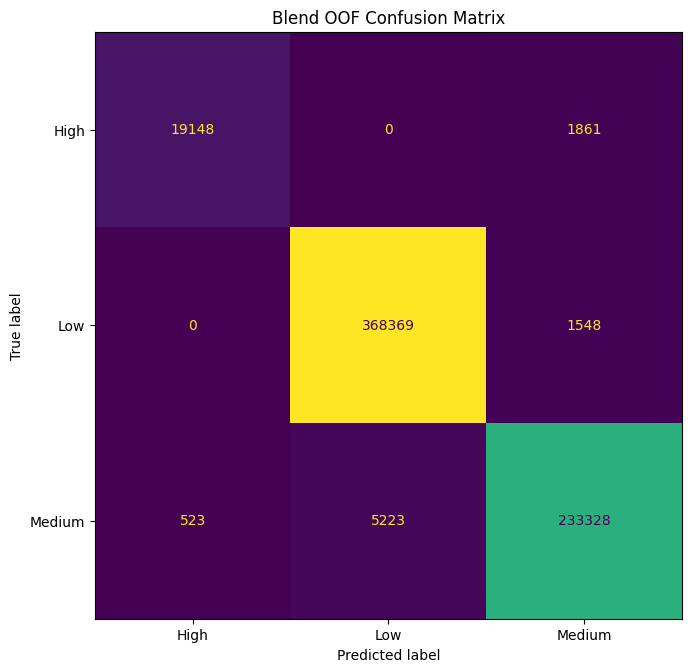

saved: report_figures\05_blend_confusion_matrix.png


,model,weight
0,rf,0.612876
1,lgbm,0.167739
2,cat,0.104808
3,xgb,0.061022
4,hgb,0.053556
5,et,0.000000
6,nn,0.000000
7,lr,0.000000


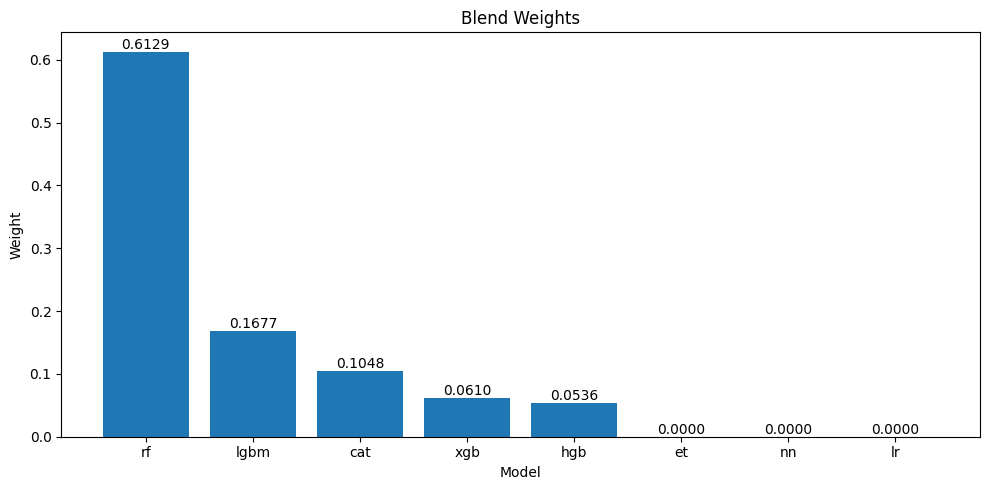

saved: report_figures\06_blend_weights.png


In [11]:
# 5) blending 混淆矩阵
cm = confusion_matrix(y_code, blend_oof_pred)
fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, values_format="d", colorbar=False)
ax.set_title("Blend OOF Confusion Matrix")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_blend_confusion_matrix.png"), dpi=220, bbox_inches="tight")
plt.show()

print("saved:", os.path.join(FIG_DIR, "05_blend_confusion_matrix.png"))

# 6) blending 权重图
weights_df = (
    pd.DataFrame({"model": list(weights.keys()), "weight": list(weights.values())})
    .sort_values("weight", ascending=False)
    .reset_index(drop=True)
)
display(weights_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(weights_df["model"], weights_df["weight"])
ax.set_title("Blend Weights")
ax.set_xlabel("Model")
ax.set_ylabel("Weight")
for i, v in enumerate(weights_df["weight"]):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "06_blend_weights.png"), dpi=220, bbox_inches="tight")
plt.show()

print("saved:", os.path.join(FIG_DIR, "06_blend_weights.png"))

,feature,importance
0,Soil_Moisture,0.216377
1,Crop_Growth_Stage_Harvest,0.103722
2,Crop_Growth_Stage_Sowing,0.099113
3,Wind_Speed_kmh,0.098400
4,Temperature_C,0.097320
5,Mulching_Used_Yes,0.085028
6,Rainfall_mm,0.048379
7,Crop_Growth_Stage_Vegetative,0.031921
8,Previous_Irrigation_mm,0.024286
9,Humidity,0.022978


importance models used: [('rf', 0.6128755853331707), ('xgb', 0.06102220074278405), ('lgbm', 0.16773879823017607), ('cat', 0.10480782142085304)]


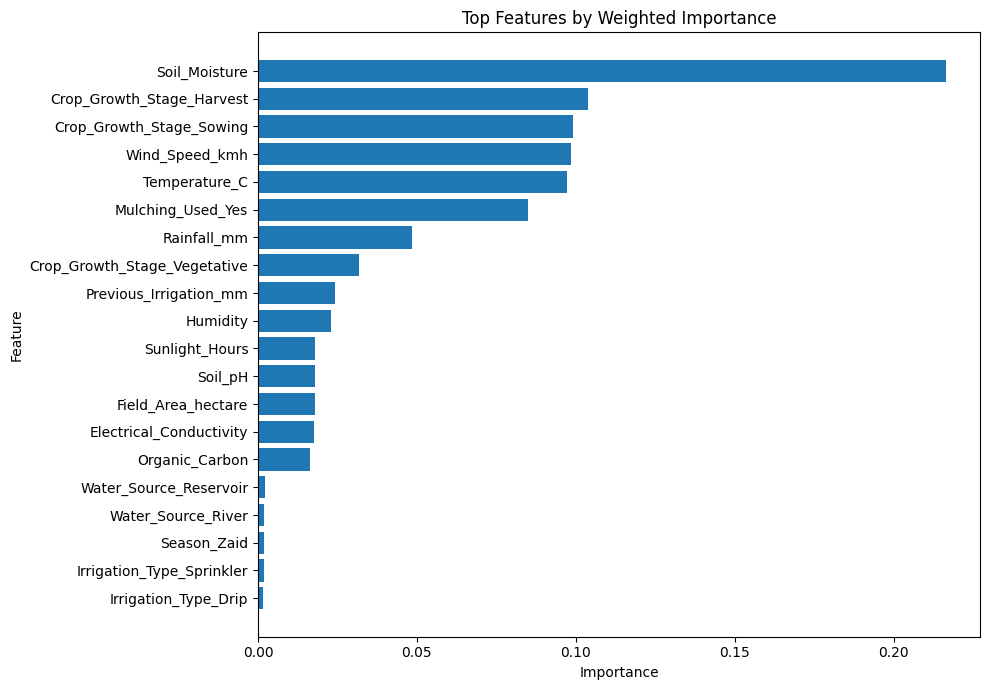

saved: report_figures\07_weighted_feature_importance_top20.png


In [12]:
# 7) 计算融合后的加权特征重要性
mean_importance_by_model = {}
for name, arr_list in feature_importance_records.items():
    if len(arr_list) == 0:
        continue
    arr = np.vstack(arr_list)
    imp = np.mean(arr, axis=0).astype(np.float64)
    imp = np.nan_to_num(imp, nan=0.0, posinf=0.0, neginf=0.0)
    if imp.sum() > 0:
        imp = imp / imp.sum()
    mean_importance_by_model[name] = imp

weighted_importance = np.zeros(len(feature_names), dtype=np.float64)
used_importance_models = []
for name, imp in mean_importance_by_model.items():
    wt = weights.get(name, 0.0)
    if wt > 0:
        weighted_importance += wt * imp
        used_importance_models.append((name, wt))

if weighted_importance.sum() <= 0 and len(mean_importance_by_model) > 0:
    for imp in mean_importance_by_model.values():
        weighted_importance += imp

feature_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": weighted_importance
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df.head(20))
print("importance models used:", used_importance_models)

plot_top_n = min(20, len(feature_importance_df))
plot_df = feature_importance_df.head(plot_top_n).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df["feature"], plot_df["importance"])
ax.set_title("Top Features by Weighted Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "07_weighted_feature_importance_top20.png"), dpi=220, bbox_inches="tight")
plt.show()

print("saved:", os.path.join(FIG_DIR, "07_weighted_feature_importance_top20.png"))

## 各个 blending 基模型的单独图像


1. 每个基模型各自的 OOF 混淆矩阵
2. 有可解释性的模型（LR / RF / ET / XGB / LGBM / CAT）的 Top 特征图


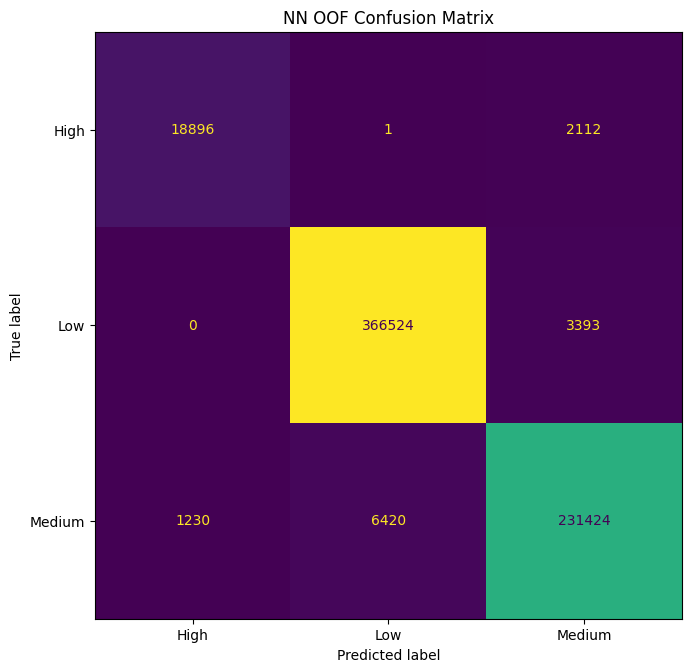

saved: report_figures\08_confusion_matrix_nn.png


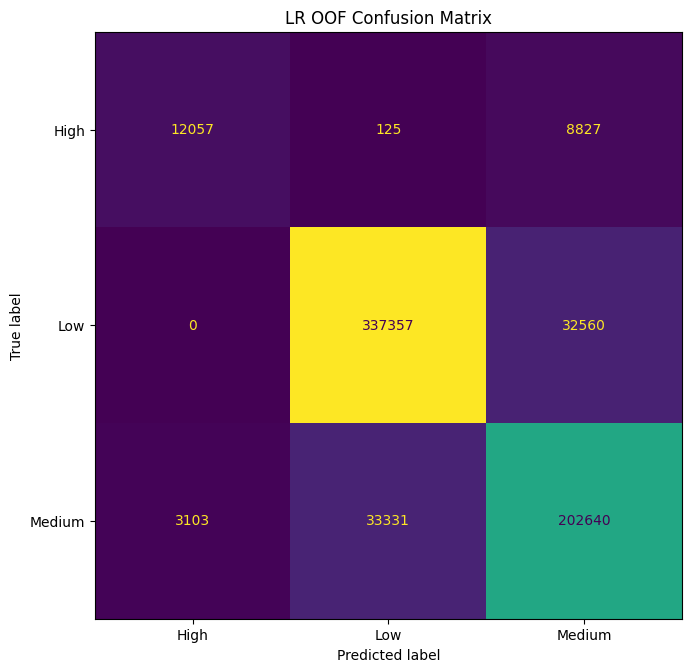

saved: report_figures\08_confusion_matrix_lr.png


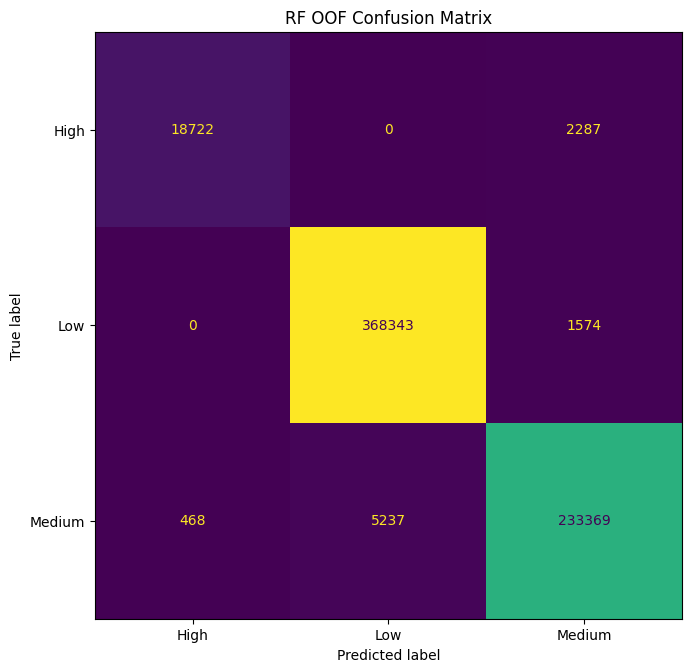

saved: report_figures\08_confusion_matrix_rf.png


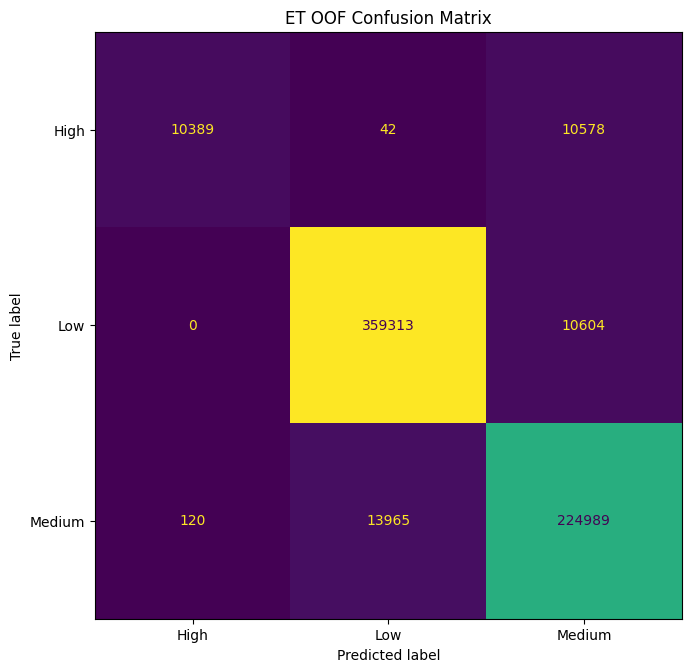

saved: report_figures\08_confusion_matrix_et.png


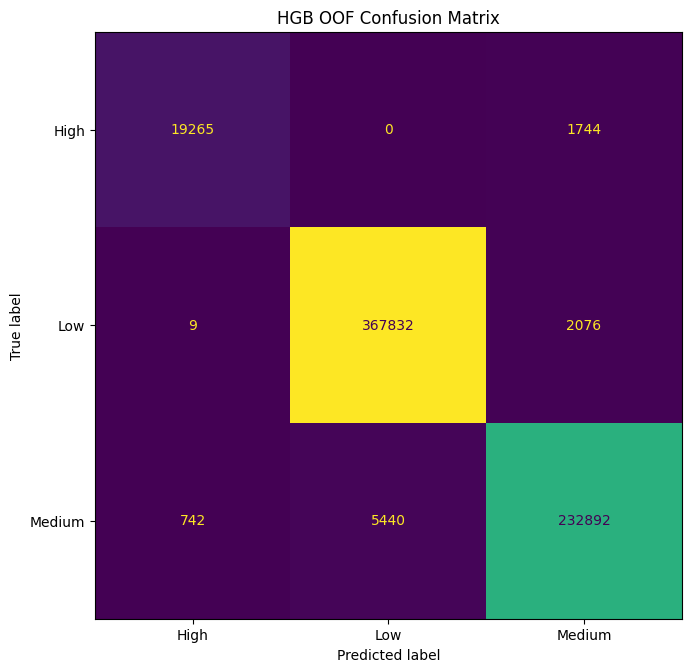

saved: report_figures\08_confusion_matrix_hgb.png


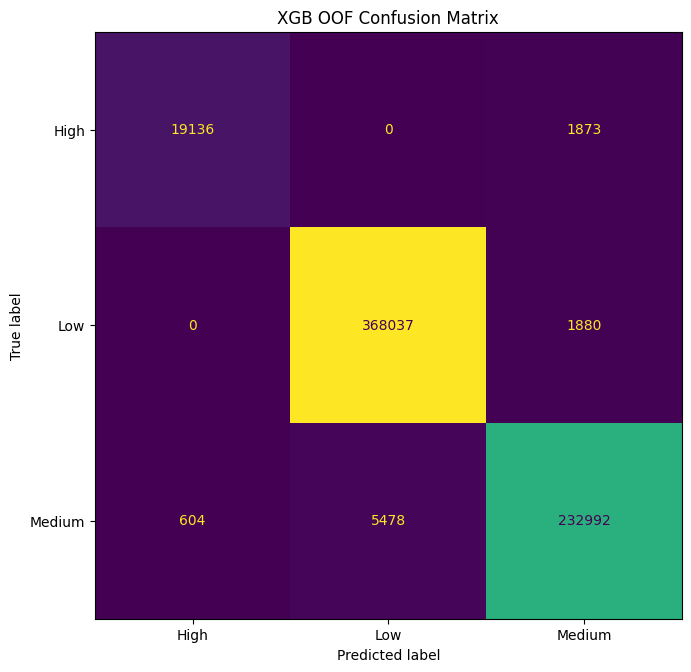

saved: report_figures\08_confusion_matrix_xgb.png


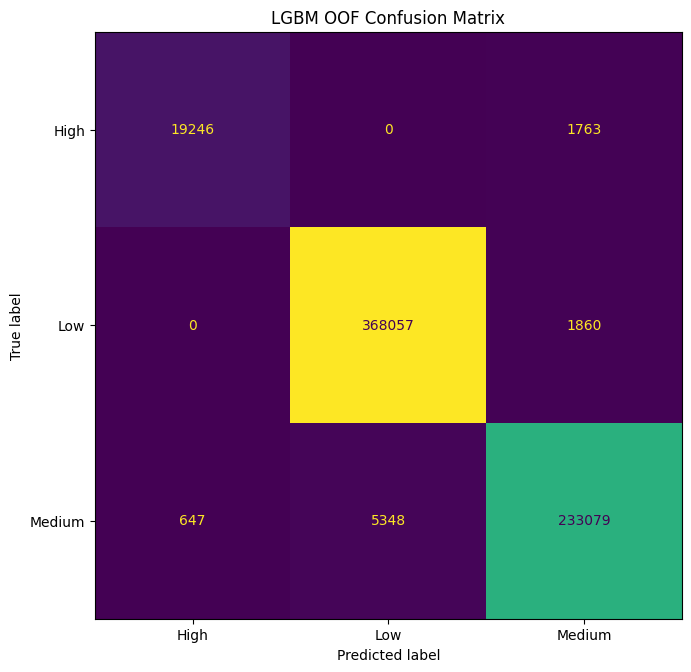

saved: report_figures\08_confusion_matrix_lgbm.png


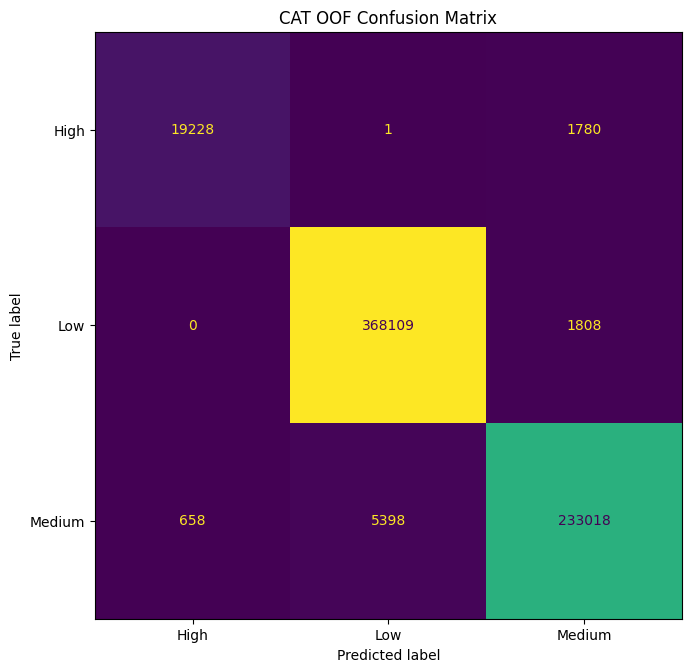

saved: report_figures\08_confusion_matrix_cat.png


,feature,importance
0,Soil_Moisture,0.179317
1,Crop_Growth_Stage_Sowing,0.161147
2,Crop_Growth_Stage_Harvest,0.161133
3,Temperature_C,0.117522
4,Mulching_Used_Yes,0.112317
5,Wind_Speed_kmh,0.099335
6,Rainfall_mm,0.051532
7,Water_Source_River,0.012828
8,Water_Source_Reservoir,0.010105
9,Crop_Type_Rice,0.008501


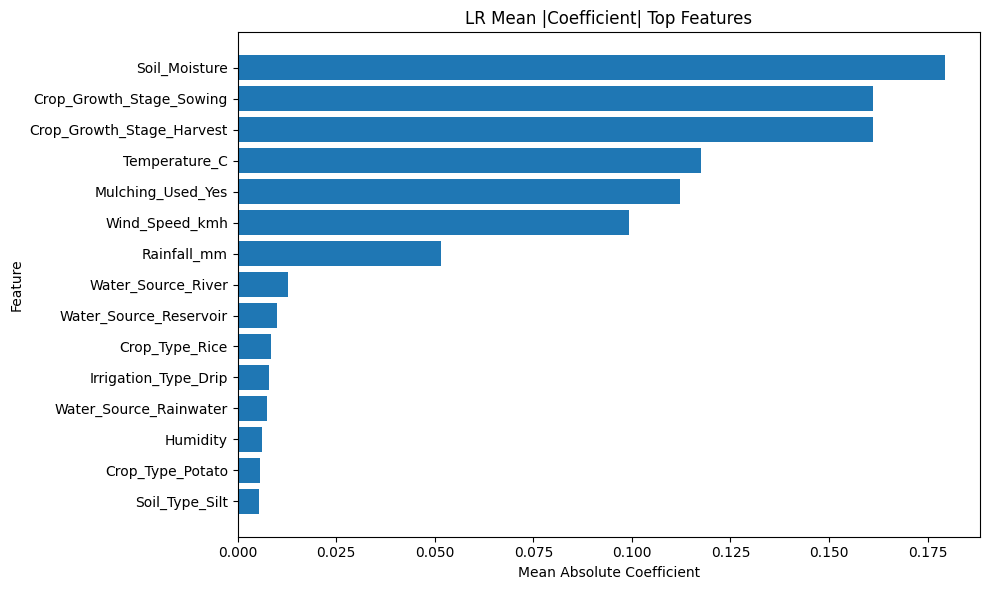

saved: report_figures\09_feature_importance_lr.png


,feature,importance
0,Soil_Moisture,0.271276
1,Crop_Growth_Stage_Harvest,0.124970
2,Crop_Growth_Stage_Sowing,0.117965
3,Wind_Speed_kmh,0.109859
4,Temperature_C,0.105231
5,Mulching_Used_Yes,0.102786
6,Crop_Growth_Stage_Vegetative,0.040623
7,Rainfall_mm,0.037694
8,Previous_Irrigation_mm,0.013432
9,Humidity,0.011595


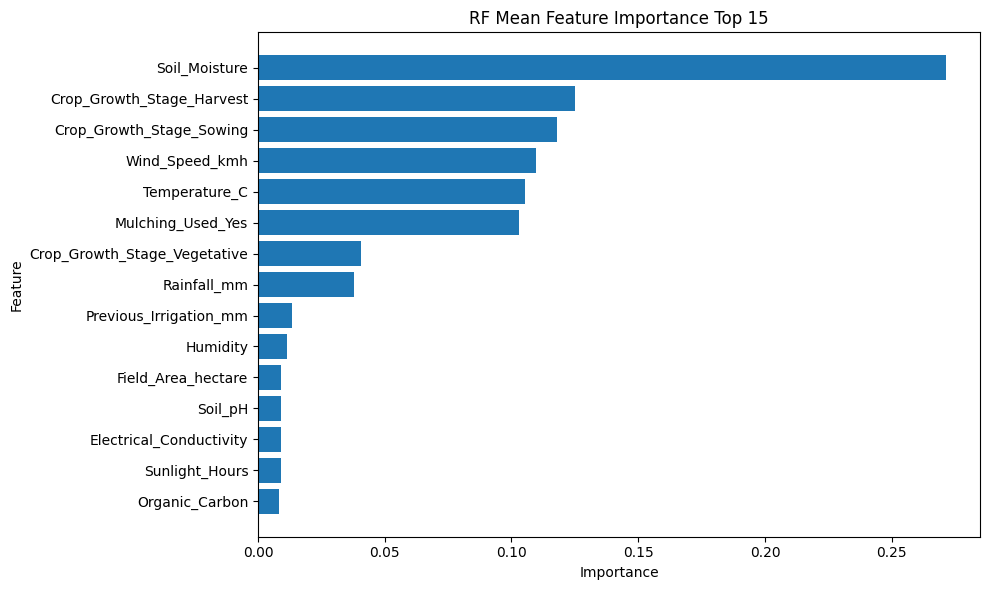

saved: report_figures\09_feature_importance_rf.png


,feature,importance
0,Soil_Moisture,0.224176
1,Crop_Growth_Stage_Harvest,0.133981
2,Crop_Growth_Stage_Sowing,0.131433
3,Mulching_Used_Yes,0.094158
4,Wind_Speed_kmh,0.082544
5,Temperature_C,0.081339
6,Crop_Growth_Stage_Vegetative,0.045733
7,Rainfall_mm,0.027361
8,Previous_Irrigation_mm,0.013164
9,Humidity,0.011844


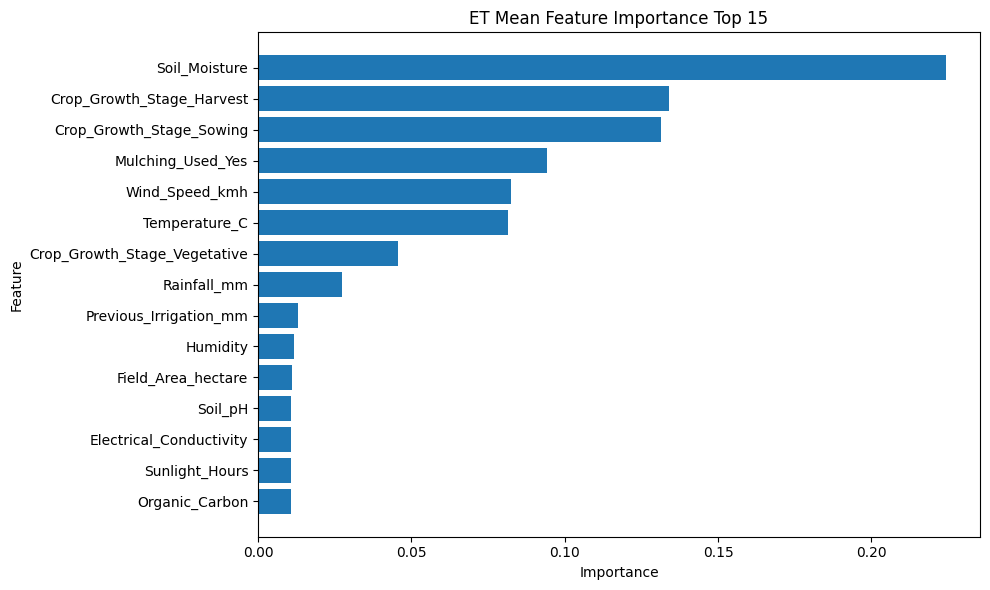

saved: report_figures\09_feature_importance_et.png


,feature,importance
0,Soil_Moisture,0.181003
1,Crop_Growth_Stage_Sowing,0.172109
2,Crop_Growth_Stage_Harvest,0.145388
3,Mulching_Used_Yes,0.133194
4,Wind_Speed_kmh,0.110973
5,Temperature_C,0.098694
6,Crop_Growth_Stage_Vegetative,0.081506
7,Rainfall_mm,0.025516
8,Previous_Irrigation_mm,0.006928
9,Soil_pH,0.004763


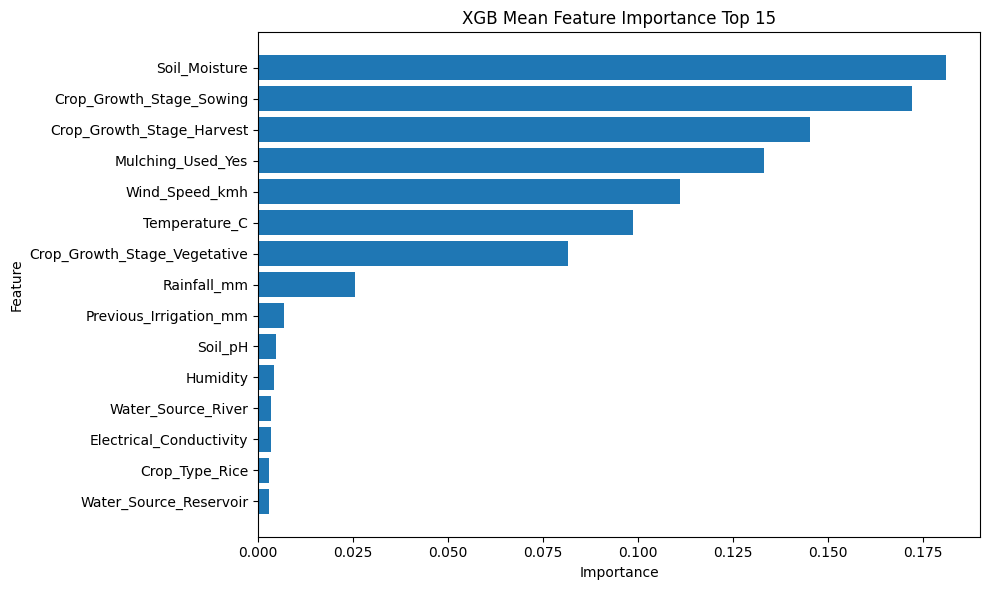

saved: report_figures\09_feature_importance_xgb.png


,feature,importance
0,Rainfall_mm,0.111581
1,Temperature_C,0.094857
2,Soil_Moisture,0.093077
3,Wind_Speed_kmh,0.084118
4,Previous_Irrigation_mm,0.077622
5,Humidity,0.074726
6,Field_Area_hectare,0.063900
7,Sunlight_Hours,0.063677
8,Soil_pH,0.062906
9,Electrical_Conductivity,0.061801


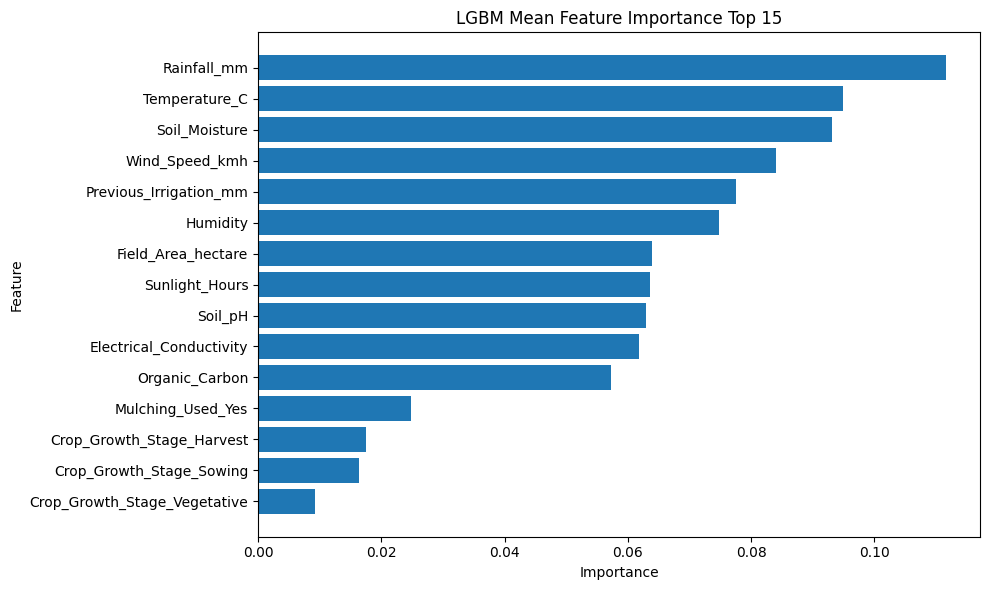

saved: report_figures\09_feature_importance_lgbm.png


,feature,importance
0,Soil_Moisture,0.223842
1,Crop_Growth_Stage_Harvest,0.146254
2,Crop_Growth_Stage_Sowing,0.129375
3,Temperature_C,0.103936
4,Wind_Speed_kmh,0.097214
5,Mulching_Used_Yes,0.092833
6,Rainfall_mm,0.047745
7,Humidity,0.029338
8,Previous_Irrigation_mm,0.024910
9,Sunlight_Hours,0.015607


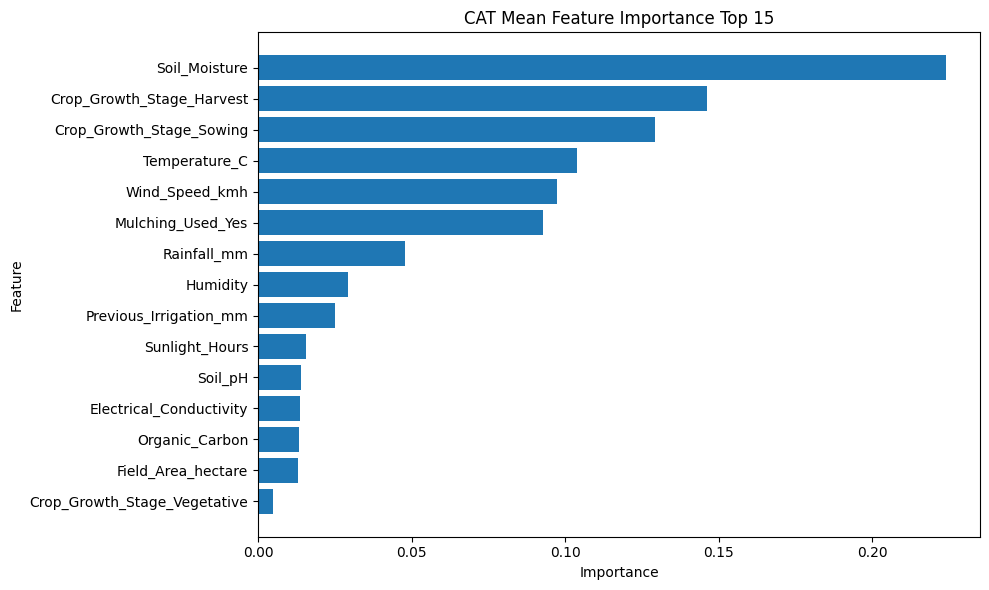

saved: report_figures\09_feature_importance_cat.png


In [13]:
# 8) 各个 blending 基模型的 OOF 混淆矩阵
for name in model_names:
    model_pred = np.argmax(oof_probs[name], axis=1)
    cm_model = confusion_matrix(y_code, model_pred)

    fig, ax = plt.subplots(figsize=(7, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_model, display_labels=class_names)
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"{name.upper()} OOF Confusion Matrix")
    fig.tight_layout()

    save_path = os.path.join(FIG_DIR, f"08_confusion_matrix_{name}.png")
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("saved:", save_path)

# 9) 各个可解释基模型的 Top 特征图
importance_top_n = 15
per_model_importance_tables = {}

for name in ["lr", "rf", "et", "xgb", "lgbm", "cat"]:
    if name not in mean_importance_by_model:
        continue

    imp = np.asarray(mean_importance_by_model[name], dtype=np.float64)
    imp = np.nan_to_num(imp, nan=0.0, posinf=0.0, neginf=0.0)

    imp_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": imp
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    per_model_importance_tables[name] = imp_df
    display(imp_df.head(importance_top_n))

    plot_df = imp_df.head(importance_top_n).sort_values("importance", ascending=True)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(plot_df["feature"], plot_df["importance"])
    if name == "lr":
        ax.set_title("LR Mean |Coefficient| Top Features")
        ax.set_xlabel("Mean Absolute Coefficient")
    else:
        ax.set_title(f"{name.upper()} Mean Feature Importance Top {importance_top_n}")
        ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    fig.tight_layout()

    save_path = os.path.join(FIG_DIR, f"09_feature_importance_{name}.png")
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("saved:", save_path)



In [14]:
# 生成提交文件
pred_idx = np.argmax(blend_test_prob, axis=1)
pred_label = [class_names[i] for i in pred_idx]

submission = sample_submission.copy()
submission["Irrigation_Need"] = pred_label
submission.to_csv("submission_blend_kfold_xgb_lgbm_cat.csv", index=False)

print(submission.head())
print("saved: submission_blend_kfold_xgb_lgbm_cat.csv")


       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
saved: submission_blend_kfold_xgb_lgbm_cat.csv
